In [59]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [60]:
#bajar datos de yahoo finance

today = pd.Timestamp.today()
start = today -pd.Timedelta(days=365)
start_date = start.strftime('%Y-%m-%d')
start_date

'2025-09-21'

In [61]:
symbol = "spy"
df_stock = yf.download(symbol, start=start_date, end=today.strftime('%Y-%m-%d'))[["Close"]].copy()
df_stock

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,SPY
Date,
2025-09-22,659.722534
2025-09-23,656.131287
2025-09-24,654.043762
2025-09-25,651.026306
2025-09-26,654.756042
...,...
2026-09-14,758.995239
2026-09-15,755.513916


In [62]:
##calcular los retornos algoritmicos diarios
#lo vamos a utilizar para facilitar la simulacion y estadistica
#Generar simetria en la distribucion de los retornos(normal)
df_stock["returns"] = np.log(df_stock["Close"] / df_stock["Close"].shift(1))

In [63]:
#Determinar media y desviacion estandar de los retornos
means_returns=df_stock["returns"].mean()
std_returns=df_stock["returns"].std()
means_returns, std_returns

(np.float64(0.0005771899923739452), np.float64(0.00815579817975679))

In [64]:
#definir la funcion de montecarlo
def montecarlo_simulation(df_prices, n_simulaciones=1000, n_days=30, mu=0, sigma=0):
    #Inicialiszar un array para almacenar los resultados de las simulaciones 1000*30
    simulated_prices=np.zeros((n_simulaciones, n_days))
    #El primer es el ultimo precio de cierre del dataframe
    initial_price=df_prices["Close"].iloc[-1]
    simulated_prices[:,0]=initial_price

    #Simular los precios para cada dia
    for i in range(1, n_days):
        simulated_prices[:,i]=simulated_prices[:,i-1]*(1+np.random.normal(mu,sigma,n_simulaciones))
    return simulated_prices

In [65]:
#Ejecutar la simulacion
simulated_prices=montecarlo_simulation(df_stock, n_simulaciones=1000, n_days=30, mu=means_returns, sigma=std_returns)
simulated_prices


array([[761.69000244, 760.1629078 , 763.98987351, ..., 729.55701889,
        722.52060058, 713.26278524],
       [761.69000244, 769.54839649, 779.09939591, ..., 782.44580154,
        779.0206922 , 781.30356516],
       [761.69000244, 752.03549051, 751.64343368, ..., 819.37963657,
        822.08248099, 820.8328311 ],
       ...,
       [761.69000244, 762.83094975, 759.57354705, ..., 805.4828862 ,
        802.76866127, 799.57570532],
       [761.69000244, 763.0087103 , 763.02437252, ..., 771.9038362 ,
        771.54585709, 769.23979338],
       [761.69000244, 761.97898833, 754.95699686, ..., 754.70702642,
        756.11389974, 745.04526316]], shape=(1000, 30))

In [66]:
#perentiles y niveles de cofianza
percentil_2_5=np.percentile(simulated_prices[:,-1], 2.5)
percentil_97_5=np.percentile(simulated_prices[:,-1], 97.5)
print(f"Percentil 2.5%: {percentil_2_5}")
print(f"Percentil 97.5%: {percentil_97_5}")


Percentil 2.5%: 711.5439971200791
Percentil 97.5%: 845.0196339759747


In [67]:
#valor esperado la media de los precios simulados al final del periodo
expected_value = np.mean(simulated_prices[:,-1]) 
print(f"El valor esperado del precio de cierre a 30 dias: {expected_value}")

El valor esperado del precio de cierre a 30 dias: 773.4584637525679


In [68]:
#calculo de var
confidence_interval = 0.95
simulated_prices_flat = np.sort(simulated_prices[:,-1].flatten())
VaR=-np.percentile(simulated_prices_flat, 100*(1-confidence_interval))
print(f"El valor en riesgo (VaR) a 30 dias con un nivel de confianza del {confidence_interval*100}% es: {VaR}")


El valor en riesgo (VaR) a 30 dias con un nivel de confianza del 95.0% es: -720.1798727670915


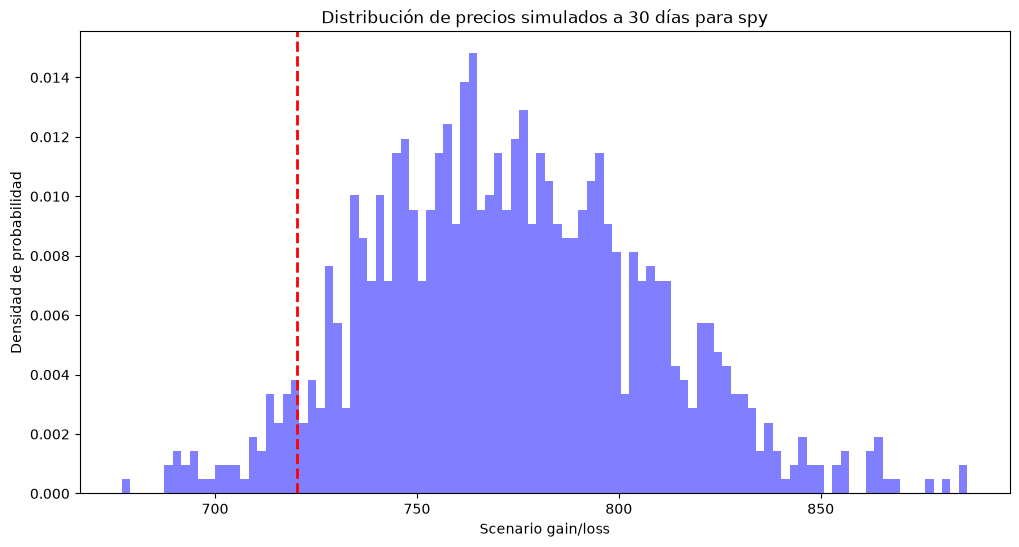

In [69]:
plt.figure(figsize=(12,6))
plt.hist(simulated_prices_flat, bins=100, density=True, alpha=0.5, color='blue')
plt.title(f"Distribución de precios simulados a 30 días para {symbol}")
plt.xlabel("Scenario gain/loss")
plt.ylabel("Densidad de probabilidad")
plt.axvline(-VaR, color='red', linestyle='--', linewidth=2, label=f'VaR con un intervalo de confianza del {confidence_interval*100}% {-VaR:.2f}')